In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (train_test_split,
                                     GridSearchCV,
                                     cross_val_score,
                                     StratifiedKFold)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier)

# Metrics
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              confusion_matrix,
                              RocCurveDisplay,
                              ConfusionMatrixDisplay)

# Save model
import joblib

# Settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Import สำเร็จทุกอย่าง ✅")

Import สำเร็จทุกอย่าง ✅


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Data Dictionary.xls to Data Dictionary.xls
Saving cs-test.csv to cs-test.csv
Saving cs-training.csv to cs-training.csv
Saving sampleEntry.csv to sampleEntry.csv


In [6]:
df = pd.read_csv('cs-training.csv', index_col=0)
print(f"Shape: {df.shape}")
df.head()

Shape: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [7]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Data Types ===
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

=== Basic Statistics ===


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [8]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_count'] > 0])

                    missing_count  missing_pct
MonthlyIncome               29731        19.82
NumberOfDependents           3924         2.62


In [9]:
print("อายุ 0 ปี:", (df['age'] == 0).sum(), "คน")
print("RevolvingUtilization > 1:",
      (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum(), "คน")

อายุ 0 ปี: 1 คน
RevolvingUtilization > 1: 3321 คน


In [12]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_count'] > 0])

                    missing_count  missing_pct
MonthlyIncome               29731        19.82
NumberOfDependents           3924         2.62


In [13]:
print("อายุ 0 ปี:", (df['age'] == 0).sum(), "คน")
print("RevolvingUtilization > 1:",
      (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum(), "คน")

อายุ 0 ปี: 1 คน
RevolvingUtilization > 1: 3321 คน


/tmp/ipykernel_12063/2193561819.py:23: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12063/2193561819.py:23: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12063/2193561819.py:23: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12063/2193561819.py:23: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12063/2193561819.py:23: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12063/2193561819.py:23: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12063/2193561819.py:23: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) D

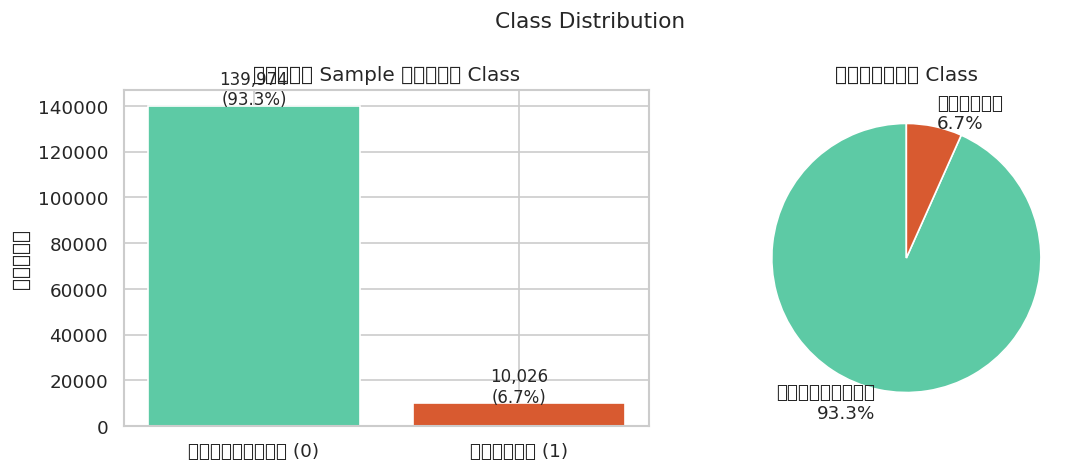

In [14]:
counts = df['SeriousDlqin2yrs'].value_counts()
pcts = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['ไม่ผิดนัด (0)', 'ผิดนัด (1)'],
            counts.values,
            color=['#5DCAA5', '#D85A30'])
axes[0].set_title('จำนวน Sample แต่ละ Class')
axes[0].set_ylabel('จำนวน')
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, c + 500, f'{c:,}\n({p:.1f}%)',
                 ha='center', fontsize=10)

axes[1].pie(counts.values,
            labels=[f'ไม่ผิดนัด\n{pcts[0]:.1f}%',
                    f'ผิดนัด\n{pcts[1]:.1f}%'],
            colors=['#5DCAA5', '#D85A30'],
            startangle=90)
axes[1].set_title('สัดส่วน Class')

plt.suptitle('Class Distribution', fontsize=13)
plt.tight_layout()
plt.show()

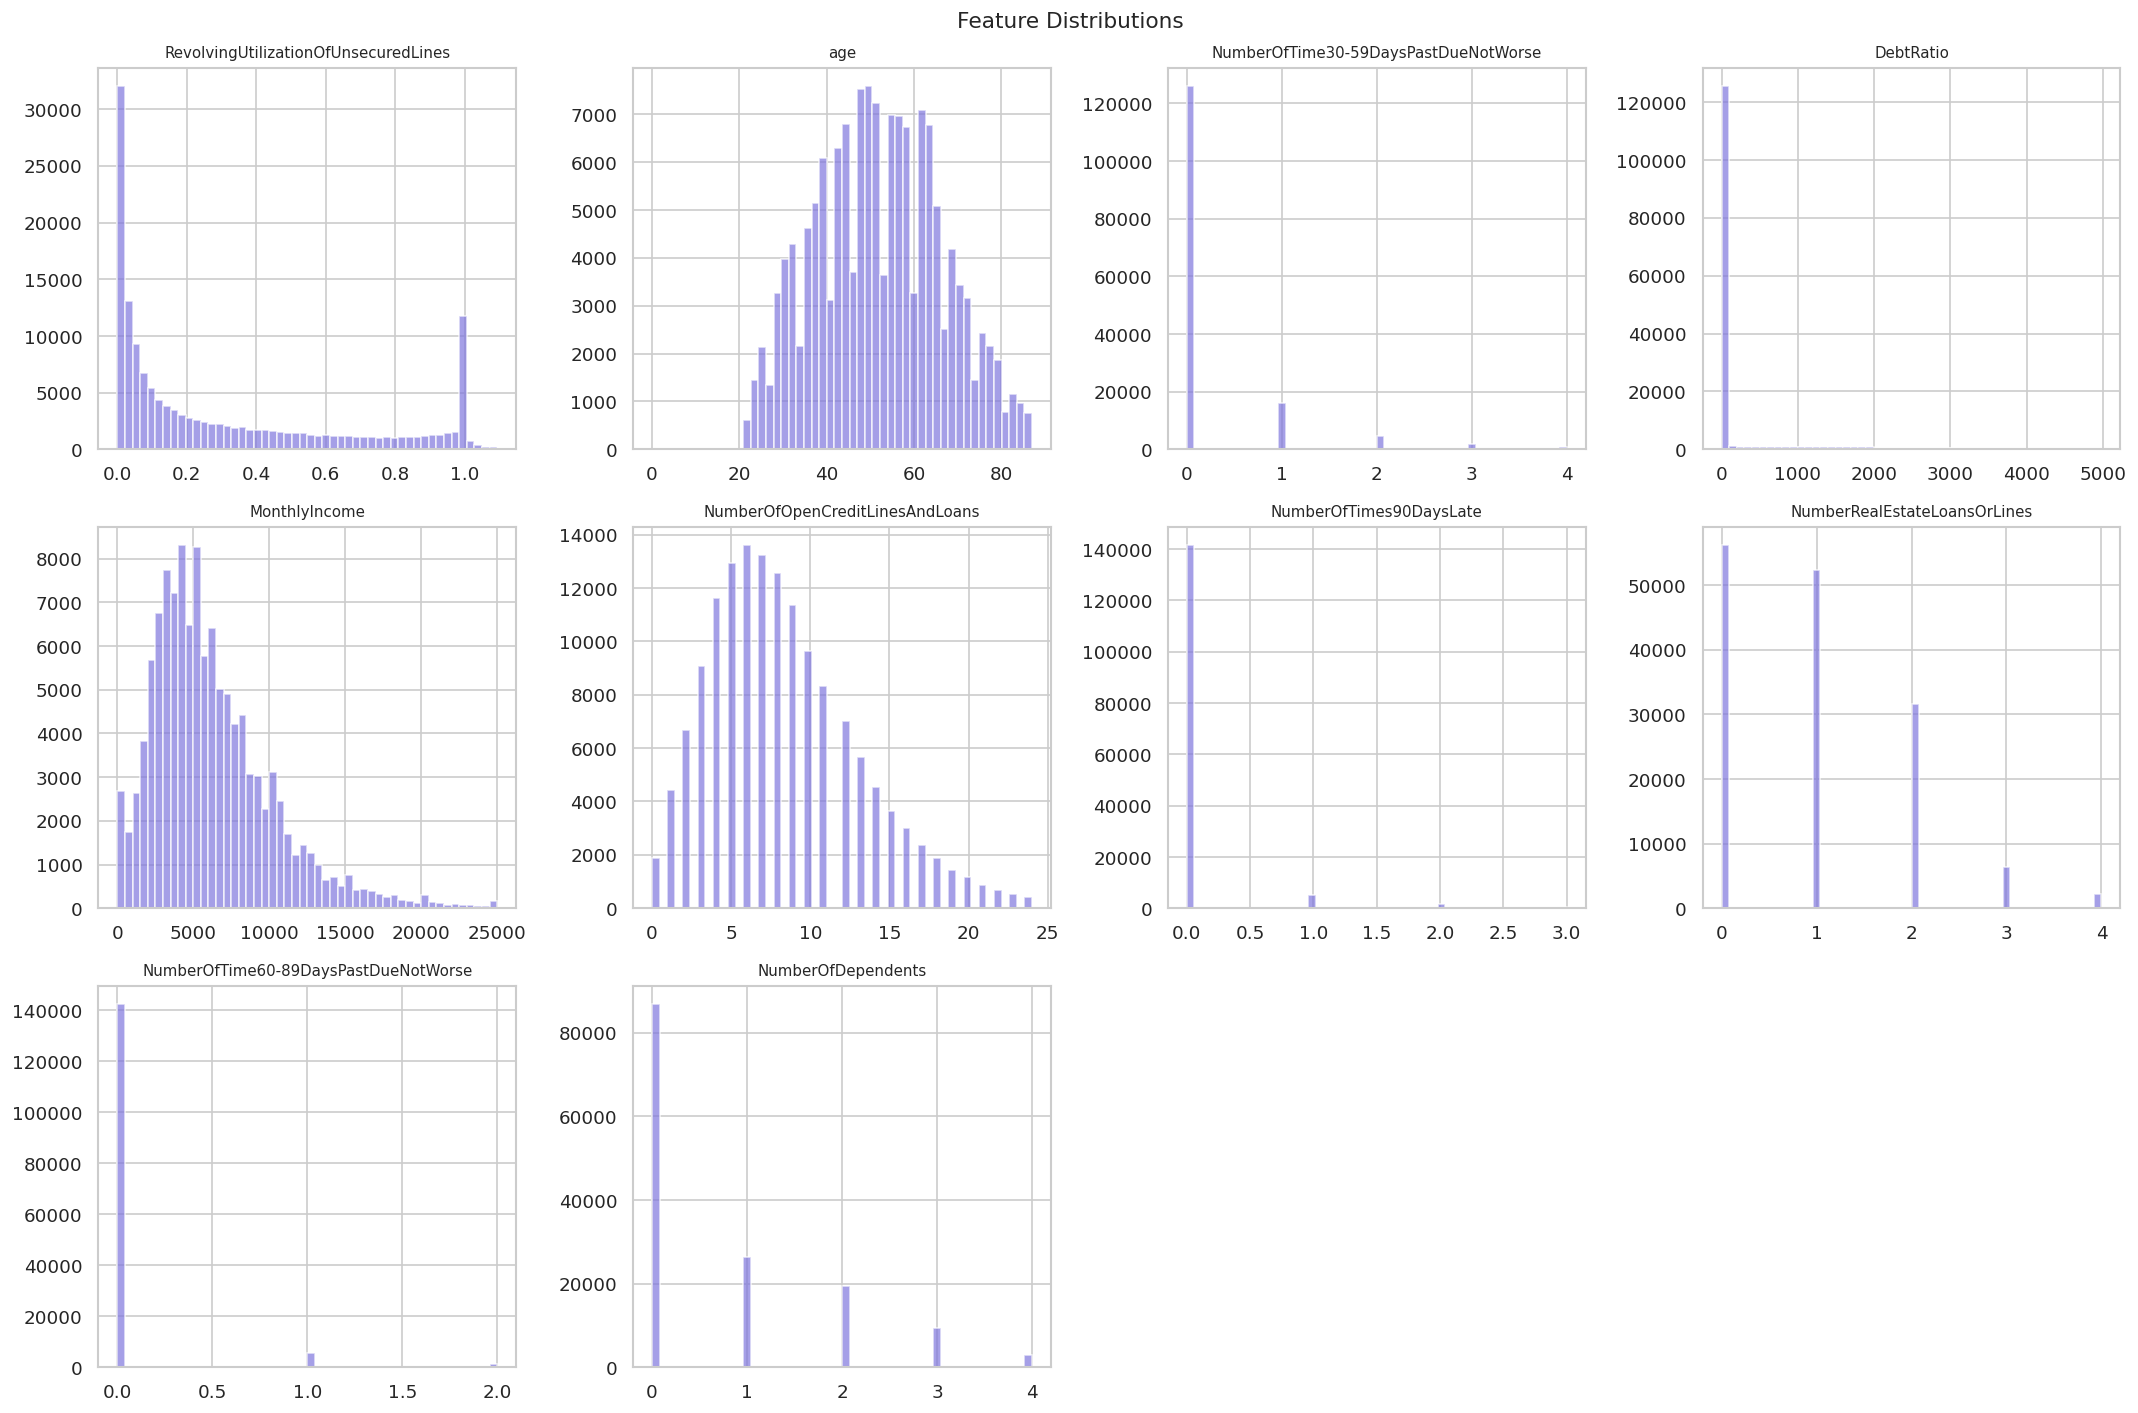

In [15]:
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    cap = data.quantile(0.99)
    data = data[data <= cap]
    axes[i].hist(data, bins=50, color='#7F77DD', alpha=0.7)
    axes[i].set_title(col, fontsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

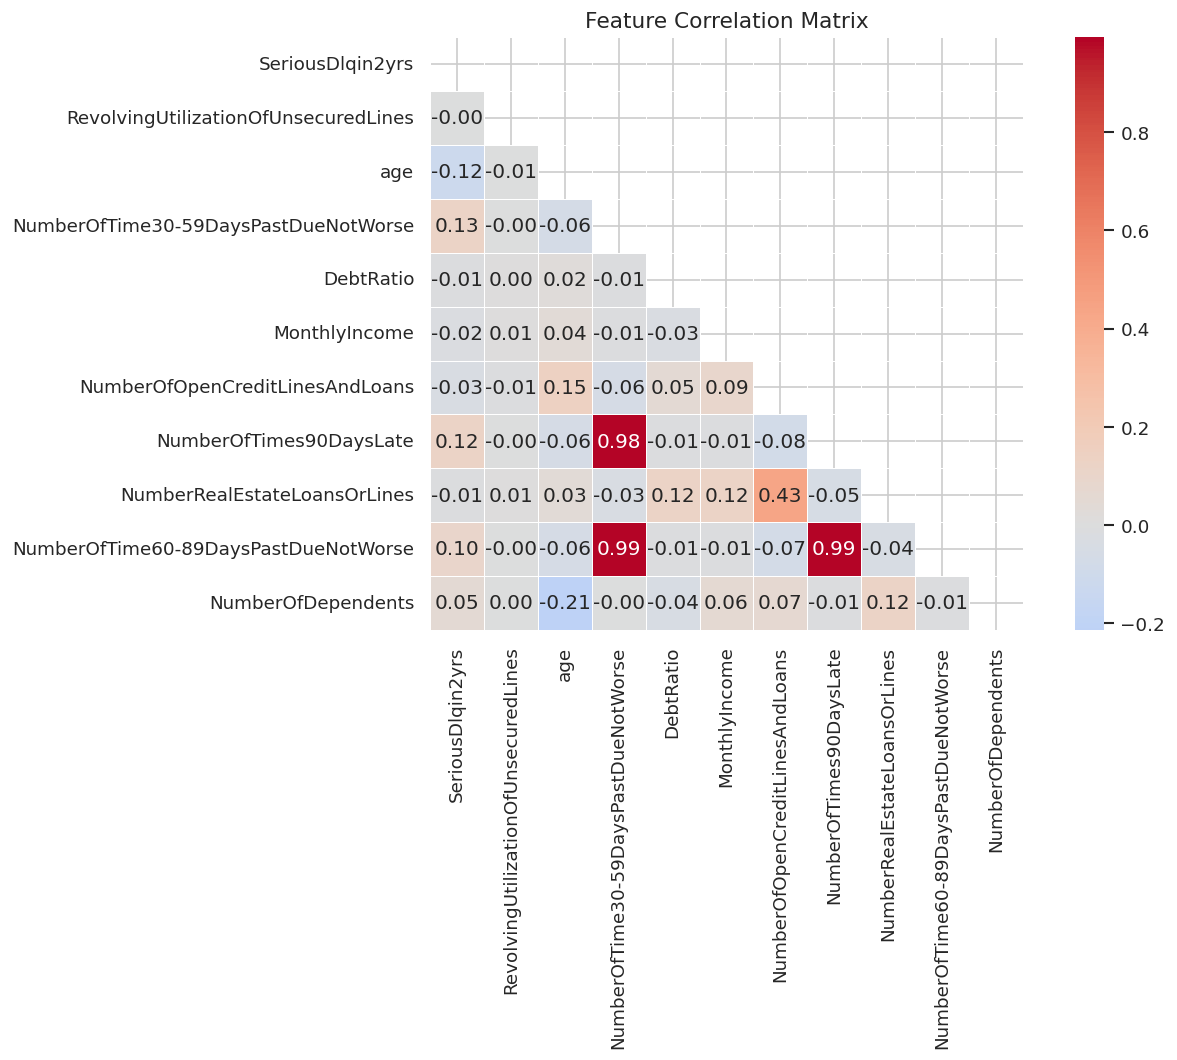

In [16]:
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()